# Data Ingestion, Cleaning & Preprocessing with Pandas

**Dataset:** `raw_retail_sales.csv` - an e-commerce order extract (12,420 rows, 13 columns, 2023-2025, amounts in INR).
**Important:** this dataset is **synthetic**. It was generated by `dataset_generation.py` (seeded, reproducible) with realistic defects injected at known rates: missing values in several spellings, duplicate and near-duplicate records, mixed date formats, currency strings in numeric columns, inconsistent category spellings and impossible values. Because the defects are known, the final cell can check the cleaning result against `generation_log.json`.

**Goal:** load -> profile ("before") -> fix types -> standardize text -> remove duplicates -> handle invalid values & outliers -> impute missing values -> engineer features -> validate -> export `clean_dataset.csv` -> prove the improvement ("after").

**Files needed in the same folder:** `raw_retail_sales.csv` (and optionally `generation_log.json`).

## 1. Load the raw data

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 180)

RAW_PATH = "raw_retail_sales.csv"
MISSING_TOKENS = ["", "NA", "N/A", "null", "-"]          # every way "missing" is written in this extract
DATE_MIN, DATE_MAX = pd.Timestamp("2023-01-01"), pd.Timestamp("2025-12-31")   # business window of the data

# Read EVERYTHING as text and switch off pandas' automatic NA handling, so nothing is silently coerced.
raw = pd.read_csv(RAW_PATH, dtype=str, keep_default_na=False, encoding="utf-8")
print("shape:", raw.shape)
raw.info()
display(raw.head(10))

shape: (12420, 13)
<class 'pandas.DataFrame'>
RangeIndex: 12420 entries, 0 to 12419
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   order_id         12420 non-null  str  
 1   order_date       12420 non-null  str  
 2   customer_id      12420 non-null  str  
 3   category         12420 non-null  str  
 4   product          12420 non-null  str  
 5   region           12420 non-null  str  
 6   quantity         12420 non-null  str  
 7   unit_price       12420 non-null  str  
 8   cost_price       12420 non-null  str  
 9   discount_pct     12420 non-null  str  
 10  payment_method   12420 non-null  str  
 11  payment_status   12420 non-null  str  
 12  customer_rating  12420 non-null  str  
dtypes: str(13)
memory usage: 1.2 MB


,order_id,order_date,customer_id,category,product,region,quantity,unit_price,cost_price,discount_pct,payment_method,payment_status,customer_rating
0,ORD-100001,2023-01-01,C00910,fashion,Sunglasses,,4,1221.84,705.68,0%,Debit Card,Pending,3
1,ORD-100002,01/01/2023,C02999,Books & Stationery,Pen Set,south,2,247.63,166.18,0,UPI,Paid,3.0
2,ORD-100003,2023-01-01,C02593,FASHION,Running Shoes,SOUTH,1,3310.94,1901.35,10,Credit Card,Pending,5
3,ORD-110685,25.09.2025,C02337,Home & Kitchen,Mixer Grinder,North,2,4059.20,2533.72,5,Credit Card,Paid,4
4,ORD-100004,2023-01-01,C02160,Home & Kitchen,Mixer Grinder,South,2,Rs. 4179.70,2506.62,15,Credit Card,Paid,NA
5,ORD-100005,"Jan 01, 2023",C00565,Fashion,T-Shirt,South,,647.24,385.32,10,Credit Card,Paid,2.0
6,ORD-100006,01/01/2023,C01888,Electronics,Bluetooth Speaker,South,1,3405.17,2420.49,10,cod,Paid,5
7,ORD-100007,2023-01-01,C02499,Fashion,Backpack,South,-1,"₹1,770.65",1000.30,0%,Credit Card,Paid,NA
8,ORD-100008,2023-01-01,c01020,Beauty,Hair Dryer,North,1,Rs. 1827.61,₹930.55,0.0,Net-Banking,Paid,5
9,ORD-100009,"Jan 02, 2023",C00778,Electronics,Wireless Earbuds,C,1,2683.11,"₹1,815.48",10,null,Paid,1


## 2. "Before": profile the raw data

Everything below is measured on the untouched file so it can be compared with the clean result at the end.

In [2]:
NUMERIC_COLS = ["quantity", "unit_price", "cost_price", "discount_pct", "customer_rating"]
CAT_COLS = ["category", "product", "region", "payment_method", "payment_status"]

is_missing = raw.apply(lambda c: c.str.strip().isin(MISSING_TOKENS))
before_missing = is_missing.sum()
print("Missing values per column (any of the tokens", MISSING_TOKENS, ")")
display(pd.DataFrame({"missing": before_missing, "missing_%": (before_missing / len(raw) * 100).round(2)}))

# numeric columns that contain text that is not a plain number
plain_number = r"^-?\d+(\.\d+)?$"
before_nonnumeric = {c: int((~is_missing[c] & ~raw[c].str.strip().str.match(plain_number)).sum()) for c in NUMERIC_COLS}
print("Non-numeric text inside numeric columns (e.g. 'Rs. 1299', '10%', 'two'):", before_nonnumeric)
display(raw.loc[~is_missing["unit_price"] & ~raw["unit_price"].str.match(plain_number), "unit_price"].sample(6, random_state=1).to_frame())

# date formats: replace digits with 9 and month names with Mon to reveal the patterns
pattern = (raw["order_date"].where(~is_missing["order_date"])
           .str.replace(r"[A-Za-z]{3}", "Mon", regex=True).str.replace(r"\d", "9", regex=True))
print("Date formats present:")
display(pattern.value_counts(dropna=False).to_frame("rows"))

before_distinct = {c: raw[c][~is_missing[c]].nunique() for c in CAT_COLS}
print("Distinct spellings per categorical column:", before_distinct)
print("(true values: category 5, region 5, payment_method 5, payment_status 4, product 25)")
display(raw["category"].value_counts().to_frame("rows").T)

before_exact_dups = int(raw.duplicated().sum())
print("Exact duplicate rows:", before_exact_dups)

before = {
    "rows": len(raw),
    "exact_dups": before_exact_dups,
    "missing_cells": int(before_missing.sum()),
    "rows_with_missing_excl_rating": int(is_missing.drop(columns="customer_rating").any(axis=1).sum()),
    "nonnumeric_cells": sum(before_nonnumeric.values()),
    "date_formats": int(pattern.nunique()),
}

Missing values per column (any of the tokens ['', 'NA', 'N/A', 'null', '-'] )


,missing,missing_%
order_id,51,0.41
order_date,118,0.95
customer_id,392,3.16
category,0,0.00
product,144,1.16
region,497,4.00
quantity,251,2.02
unit_price,219,1.76
cost_price,367,2.95
discount_pct,641,5.16


Non-numeric text inside numeric columns (e.g. 'Rs. 1299', '10%', 'two'): {'quantity': 123, 'unit_price': 3583, 'cost_price': 1245, 'discount_pct': 2944, 'customer_rating': 0}


,unit_price
6558,Rs. 1677.59
2931,"₹2,952.46"
302,₹623.70
4252,Rs. 430.15
5841,"₹2,597.39"
2661,3098.00 INR


Date formats present:


,rows
order_date,
9999-99-99,6755
99/99/9999,2536
99-Mon-9999,1454
"Mon 99, 9999",1184
99.99.9999,373
NaN,118


Distinct spellings per categorical column: {'category': 23, 'product': 75, 'region': 25, 'payment_method': 21, 'payment_status': 20}
(true values: category 5, region 5, payment_method 5, payment_status 4, product 25)


category,Fashion,Home & Kitchen,Electronics,Beauty,Books & Stationery,FASHION,fashion,Fashion,ELECTRONICS,Beauty,Electronic,BEAUTY,home & kitchen,Home and Kitchen,Electronics,HOME & KITCHEN,beauty,Home & Kitchen,electronics,BOOKS & STATIONERY,Books and Stationery,books & stationery,Books & Stationary
rows,2505,2332,2276,1871,1570,164,142,135,125,113,113,112,106,105,101,101,96,92,81,75,70,68,67


Exact duplicate rows: 301


## 3. Standardize missing values and text

* Strip leading/trailing spaces in every column.
* Convert all missing tokens (`""`, `NA`, `N/A`, `null`, `-`) to a real `NaN`.
* Map each categorical spelling to one canonical value. The mapping is checked: if any value is not covered, the cell fails loudly instead of silently becoming `NaN`.

In [3]:
df = raw.copy()
df = df.apply(lambda c: c.str.strip())
df = df.replace({tok: np.nan for tok in MISSING_TOKENS})
print("missing cells after token cleanup:", int(df.isna().sum().sum()))

REGION_MAP = {"north": "North", "n": "North", "south": "South", "s": "South", "east": "East", "e": "East",
              "west": "West", "w": "West", "central": "Central", "c": "Central"}
CATEGORY_MAP = {"electronics": "Electronics", "electronic": "Electronics",
                "home & kitchen": "Home & Kitchen", "home and kitchen": "Home & Kitchen",
                "fashion": "Fashion", "beauty": "Beauty",
                "books & stationery": "Books & Stationery", "books and stationery": "Books & Stationery",
                "books & stationary": "Books & Stationery"}
PAYMENT_MAP = {"credit card": "Credit Card", "credit-card": "Credit Card", "cc": "Credit Card",
               "debit card": "Debit Card", "dc": "Debit Card",
               "upi": "UPI", "u.p.i": "UPI",
               "net banking": "Net Banking", "netbanking": "Net Banking", "net-banking": "Net Banking",
               "cod": "COD", "cash on delivery": "COD"}
STATUS_MAP = {"paid": "Paid", "pending": "Pending", "failed": "Failed", "refunded": "Refunded"}

def standardize(series, mapping, name):
    mapped = series.str.lower().map(mapping)
    unmapped = series[series.notna() & mapped.isna()].unique()
    assert len(unmapped) == 0, f"{name}: values not covered by the mapping: {unmapped}"
    return mapped

df["region"] = standardize(df["region"], REGION_MAP, "region")
df["category"] = standardize(df["category"], CATEGORY_MAP, "category")
df["payment_method"] = standardize(df["payment_method"], PAYMENT_MAP, "payment_method")
df["payment_status"] = standardize(df["payment_status"], STATUS_MAP, "payment_status")
df["customer_id"] = df["customer_id"].str.upper()

# product: the canonical spelling is the most frequent spelling of each case-insensitive name
key = df["product"].str.lower()
canonical = df.groupby(key)["product"].agg(lambda s: s.value_counts().idxmax())
df["product"] = key.map(canonical)

for c in ["category", "region", "payment_method", "payment_status", "product"]:
    print(f"{c:15s} distinct values: before {before_distinct[c]:>3d} -> after {df[c].nunique()}")
display(df["category"].value_counts().to_frame("rows").T)

missing cells after token cleanup: 6183
category        distinct values: before  23 -> after 5
region          distinct values: before  25 -> after 5
payment_method  distinct values: before  21 -> after 5
payment_status  distinct values: before  20 -> after 4
product         distinct values: before  75 -> after 25


category,Fashion,Home & Kitchen,Electronics,Beauty,Books & Stationery
rows,2946,2736,2696,2192,1850


## 4. Fix data types

* **Dates:** five different formats are present. Each is parsed with an *explicit* format (never guessing day/month order; the data uses DD/MM/YYYY). Values outside the business window (2023-01-01 to 2025-12-31) are impossible dates (the extract has year typos such as 2050) and become `NaT`.
* **Numbers:** strip currency symbols (`₹`, `Rs.`, `INR`), thousands separators, `%`, and convert number words (`two` -> 2). The code verifies that **no new** missing values are created by the conversion.

In [4]:
# ---- dates
DATE_FORMATS = ["%Y-%m-%d", "%d/%m/%Y", "%d-%b-%Y", "%b %d, %Y", "%d.%m.%Y"]
parsed = pd.Series(pd.NaT, index=df.index, dtype="datetime64[ns]")
for fmt in DATE_FORMATS:
    parsed = parsed.fillna(pd.to_datetime(df["order_date"], format=fmt, errors="coerce"))

unparseable = int((df["order_date"].notna() & parsed.isna()).sum())
out_of_window = int((parsed.notna() & ~parsed.between(DATE_MIN, DATE_MAX)).sum())
print(f"dates that matched none of the formats: {unparseable}")
print(f"dates parsed but outside {DATE_MIN.date()}..{DATE_MAX.date()} (set to NaT): {out_of_window}")
parsed = parsed.where(parsed.between(DATE_MIN, DATE_MAX))
df["order_date"] = parsed

# ---- numbers
WORD_NUMBERS = {"one": "1", "two": "2", "three": "3", "four": "4", "five": "5"}

def to_number(s):
    s = s.str.lower().replace(WORD_NUMBERS)
    s = s.str.replace(r"\brs\.?|inr|₹|,|%|\s", "", regex=True)
    return pd.to_numeric(s, errors="coerce")

for c in NUMERIC_COLS:
    na_before = int(df[c].isna().sum())
    df[c] = to_number(df[c])
    new_na = int(df[c].isna().sum()) - na_before
    assert new_na == 0, f"{c}: {new_na} values could not be parsed"
print("numeric parsing created no new missing values")
display(pd.DataFrame({"dtype_before": "text (object)", "dtype_now": df.dtypes.astype(str)}))

dates that matched none of the formats: 0
dates parsed but outside 2023-01-01..2025-12-31 (set to NaT): 17


numeric parsing created no new missing values

,dtype_before,dtype_now
order_id,text (object),str
order_date,text (object),datetime64[ns]
customer_id,text (object),str
category,text (object),str
product,text (object),str
region,text (object),str
quantity,text (object),float64
unit_price,text (object),float64
cost_price,text (object),float64
discount_pct,text (object),float64


## 5. Remove duplicates

Standardizing first matters: the same order typed with different casing, spacing or date format is *not* an exact duplicate in the raw file, but becomes one after step 3-4. Both kinds are removed (first occurrence kept).

In [5]:
rows_start = len(df)
dups_after_standardizing = int(df.duplicated().sum())
near_dups = dups_after_standardizing - before["exact_dups"]
print(f"duplicates in the raw file (exact copies):           {before['exact_dups']}")
print(f"extra duplicates revealed only after standardizing:   {near_dups}")

df = df.drop_duplicates().reset_index(drop=True)

conflicts = int(df.loc[df["order_id"].notna(), "order_id"].duplicated().sum())
print(f"order_ids that still repeat with different content:   {conflicts}")
if conflicts:
    df = df[~(df["order_id"].notna() & df["order_id"].duplicated())].reset_index(drop=True)
print("rows:", rows_start, "->", len(df))

duplicates in the raw file (exact copies):           301
extra duplicates revealed only after standardizing:   119
order_ids that still repeat with different content:   0
rows: 12420 -> 12000


## 6. Drop rows without a usable key

`order_id` and `order_date` cannot be guessed or imputed: an order without an ID cannot be tracked, and without a valid date it cannot be placed in any month or year. These rows are dropped and counted.

In [6]:
rows_before_keys = len(df)
no_id = int(df["order_id"].isna().sum())
no_date = int((df["order_id"].notna() & df["order_date"].isna()).sum())
df = df[df["order_id"].notna() & df["order_date"].notna()].reset_index(drop=True)
print(f"dropped: {no_id} rows with no order_id, {no_date} more with missing/invalid order_date")
print("rows:", rows_before_keys, "->", len(df))

dropped: 48 rows with no order_id, 130 more with missing/invalid order_date
rows: 12000 -> 11822


## 7. Invalid values and outliers

Two kinds of problem, two treatments. In both cases the bad value is **replaced by a missing value** (not clipped to a boundary), because a clearly wrong number carries no information, and the imputation in step 8 then fills it from similar rows. Every replaced cell is flagged.

| Column | Rule | Why |
|---|---|---|
| `quantity` | must be 1-10 | 0, -1, -2 are impossible; 50/99/100 are data-entry errors (typical order is 1-5) |
| `discount_pct` | must be 0-100 | a discount over 100% or below 0 is impossible |
| `unit_price`, `cost_price` | must be > 0 and inside the **extreme IQR fence** (k = 3) **within each product** | the same product should sell at about the same price; x10 typos fall far outside |

Outliers are judged *within a product*, because a global rule would call every Smart Watch an outlier next to a Pen Set.

In [7]:
def iqr_outliers(frame, col, by, k=3.0):
    g = frame.groupby(by, dropna=False)[col]
    q1, q3 = g.transform(lambda s: s.quantile(0.25)), g.transform(lambda s: s.quantile(0.75))
    iqr = q3 - q1
    return (frame[col] < q1 - k * iqr) | (frame[col] > q3 + k * iqr)

by = [df["category"], df["product"].fillna("Unknown")]
fix_log = {}

# show the problem first
display(df[["quantity", "unit_price", "discount_pct"]].describe().T[["min", "50%", "max"]])

bad_qty = df["quantity"].notna() & ~df["quantity"].between(1, 10)
bad_disc = df["discount_pct"].notna() & ~df["discount_pct"].between(0, 100)
bad_price = df["unit_price"].notna() & ((df["unit_price"] <= 0) | iqr_outliers(df, "unit_price", by))
bad_cost = df["cost_price"].notna() & ((df["cost_price"] <= 0) | iqr_outliers(df, "cost_price", by))

for name, mask, col in [("quantity outside 1-10", bad_qty, "quantity"), ("discount outside 0-100", bad_disc, "discount_pct"),
                        ("unit_price <=0 or extreme outlier", bad_price, "unit_price"), ("cost_price <=0 or extreme outlier", bad_cost, "cost_price")]:
    fix_log[name] = int(mask.sum())
    print(f"{name:38s}: {int(mask.sum()):>4d}   e.g. {df.loc[mask, col].head(5).tolist()}")
    df.loc[mask, col] = np.nan

# mark every cell that is about to be filled (originally missing OR just invalidated)
for col in ["quantity", "unit_price", "cost_price", "discount_pct"]:
    df[f"{col}_imputed"] = df[col].isna()

,min,50%,max
quantity,-2.00,1.00,100.0
unit_price,-4124.55,1747.26,58952.8
discount_pct,-5.00,5.00,150.0


quantity outside 1-10                 :   65   e.g. [-1.0, -1.0, 100.0, 100.0, 99.0]
discount outside 0-100                :   30   e.g. [150.0, 105.0, 105.0, -5.0, 105.0]
unit_price <=0 or extreme outlier     :   61   e.g. [4205.4, -3020.0, 17887.8, -247.45, 34176.0]
cost_price <=0 or extreme outlier     :    0   e.g. []


## 8. Missing values: decision per column

| Column | Missing | Decision | Reason |
|---|---|---|---|
| `unit_price` | ~2% + invalid | median of the same **product** (category median if product unknown) | price is a property of the product; the median ignores outliers |
| `cost_price` | ~3% + invalid | median of the same product (otherwise category cost ratio x unit price) | same logic; keeps margins realistic |
| `quantity` | ~2% + invalid | most common quantity (mode) in the category | quantity is a small whole number; the mode keeps it an integer |
| `discount_pct` | ~5% + invalid | **0** (no discount), flagged | a blank discount most plausibly means none was applied. It is an assumption, so `discount_pct_imputed` lets analysts exclude or test it |
| `product`, `region`, `payment_method`, `payment_status` | 1-4% | label **"Unknown"** | guessing a payment status or region would fabricate facts |
| `customer_id` | ~3% | label **"UNKNOWN"** | cannot be recovered; keeps the order for revenue totals |
| `customer_rating` | ~25% | **left empty** | too many to fill without inventing opinions; any average would distort satisfaction analysis |

In [8]:
# categorical / identifier columns
for c in ["product", "region", "payment_method", "payment_status"]:
    df[c] = df[c].fillna("Unknown")
df["customer_id"] = df["customer_id"].fillna("UNKNOWN")

known = df["product"].ne("Unknown")

# unit_price: product median, else category median
med_prod = df.groupby(["category", "product"])["unit_price"].transform("median")
med_cat = df.groupby("category")["unit_price"].transform("median")
df["unit_price"] = df["unit_price"].fillna(med_prod.where(known, med_cat))

# cost_price: product median, else category cost/price ratio x unit_price
ok = ~df["unit_price_imputed"] & ~df["cost_price_imputed"]
ratio_cat = (df["cost_price"] / df["unit_price"]).where(ok).groupby(df["category"]).transform("median")
med_prod_cost = df.groupby(["category", "product"])["cost_price"].transform("median")
df["cost_price"] = df["cost_price"].fillna(med_prod_cost.where(known, ratio_cat * df["unit_price"]))

# quantity: mode within category
mode_qty = df.groupby("category")["quantity"].transform(lambda s: s.mode().iloc[0])
df["quantity"] = df["quantity"].fillna(mode_qty).astype(int)

# discount: no discount recorded -> 0 (flagged above)
df["discount_pct"] = df["discount_pct"].fillna(0)

print("cells filled per column:")
print(df[[c for c in df.columns if c.endswith("_imputed")]].sum().to_string())
remaining = df.drop(columns=[c for c in df.columns if c.endswith("_imputed")]).isna().sum()
print("\nmissing values left (intentional):", remaining[remaining > 0].to_dict())

cells filled per column:
quantity_imputed        301
unit_price_imputed      270
cost_price_imputed      350
discount_pct_imputed    638

missing values left (intentional): {'customer_rating': 2979}


## 9. Feature engineering

* **Date parts:** year, month, month name, quarter, year-month, day of week, weekend flag.
* **Money:** `gross_amount = quantity x unit_price`, `discount_amount`, `revenue = gross - discount`, `total_cost = quantity x cost_price`, `profit = revenue - total_cost`, `profit_margin_pct = profit / revenue x 100`.
* **`counts_as_revenue`**: only `Paid` orders are realized revenue. Pending, Failed and Refunded orders keep their computed amounts, but analysts should filter on this flag before summing.

In [9]:
d = df["order_date"].dt
df["year"] = d.year
df["month"] = d.month
df["month_name"] = d.month_name()
df["quarter"] = d.quarter
df["year_month"] = d.strftime("%Y-%m")
df["day_of_week"] = d.day_name()
df["is_weekend"] = d.dayofweek >= 5

df["gross_amount"] = (df["quantity"] * df["unit_price"]).round(2)
df["discount_amount"] = (df["gross_amount"] * df["discount_pct"] / 100).round(2)
df["revenue"] = (df["gross_amount"] - df["discount_amount"]).round(2)
df["total_cost"] = (df["quantity"] * df["cost_price"]).round(2)
df["profit"] = (df["revenue"] - df["total_cost"]).round(2)
df["profit_margin_pct"] = np.where(df["revenue"] > 0, df["profit"] / df["revenue"] * 100, np.nan).round(2)
df["counts_as_revenue"] = df["payment_status"].eq("Paid")

display(df[["order_id", "order_date", "year", "month_name", "quantity", "unit_price", "discount_pct", "revenue", "profit", "profit_margin_pct"]].head(8))

,order_id,order_date,year,month_name,quantity,unit_price,discount_pct,revenue,profit,profit_margin_pct
0,ORD-100001,2023-01-01,2023,January,4,1221.84,0.0,4887.36,2064.64,42.24
1,ORD-100002,2023-01-01,2023,January,2,247.63,0.0,495.26,162.90,32.89
2,ORD-100003,2023-01-01,2023,January,1,3310.94,10.0,2979.85,1078.50,36.19
3,ORD-110685,2025-09-25,2025,September,2,4059.20,5.0,7712.48,2645.04,34.30
4,ORD-100004,2023-01-01,2023,January,2,4179.70,15.0,7105.49,2092.25,29.45
5,ORD-100005,2023-01-01,2023,January,1,647.24,10.0,582.52,197.20,33.85
6,ORD-100006,2023-01-01,2023,January,1,3405.17,10.0,3064.65,644.16,21.02
7,ORD-100007,2023-01-01,2023,January,1,1770.65,0.0,1770.65,770.35,43.51


## 10. Validate, then export `clean_dataset.csv`

In [10]:
base_cols = ["order_id", "order_date", "year", "month", "month_name", "quarter", "year_month", "day_of_week", "is_weekend",
             "customer_id", "category", "product", "region", "quantity", "unit_price", "cost_price", "discount_pct",
             "gross_amount", "discount_amount", "revenue", "total_cost", "profit", "profit_margin_pct",
             "payment_method", "payment_status", "counts_as_revenue", "customer_rating",
             "unit_price_imputed", "cost_price_imputed", "quantity_imputed", "discount_pct_imputed"]
clean = df[base_cols].sort_values("order_id").reset_index(drop=True)

# ---- validation: the export fails if any rule is broken
assert clean.duplicated().sum() == 0, "duplicate rows remain"
assert clean["order_id"].is_unique, "order_id is not unique"
assert clean[["order_id", "order_date"]].notna().all().all(), "key fields have gaps"
assert clean["order_date"].between(DATE_MIN, DATE_MAX).all(), "date outside window"
assert clean["quantity"].between(1, 10).all(), "quantity out of range"
assert (clean["unit_price"] > 0).all() and (clean["cost_price"] > 0).all(), "non-positive price/cost"
assert clean["discount_pct"].between(0, 100).all(), "discount out of range"
assert clean.drop(columns="customer_rating").isna().sum().sum() == 0, "unexpected missing values"
assert np.isfinite(clean["profit_margin_pct"]).all(), "margin has inf/NaN"
assert set(clean["category"]) <= set(CATEGORY_MAP.values()) and set(clean["payment_status"]) <= set(STATUS_MAP.values()) | {"Unknown"}
print("all validation checks passed")

clean.to_csv("clean_dataset.csv", index=False, encoding="utf-8")
check = pd.read_csv("clean_dataset.csv", parse_dates=["order_date"])
print("exported clean_dataset.csv:", check.shape, "| round-trip dtypes ok:", check["order_date"].dtype.kind == "M")
display(check.head())

all validation checks passed


exported clean_dataset.csv: (11822, 31) | round-trip dtypes ok: True


,order_id,order_date,year,month,month_name,quarter,year_month,day_of_week,is_weekend,customer_id,category,product,region,quantity,unit_price,cost_price,discount_pct,gross_amount,discount_amount,revenue,total_cost,profit,profit_margin_pct,payment_method,payment_status,counts_as_revenue,customer_rating,unit_price_imputed,cost_price_imputed,quantity_imputed,discount_pct_imputed
0,ORD-100001,2023-01-01,2023,1,January,1,2023-01,Sunday,True,C00910,Fashion,Sunglasses,Unknown,4,1221.84,705.68,0.0,4887.36,0.00,4887.36,2822.72,2064.64,42.24,Debit Card,Pending,False,3.0,False,False,False,False
1,ORD-100002,2023-01-01,2023,1,January,1,2023-01,Sunday,True,C02999,Books & Stationery,Pen Set,South,2,247.63,166.18,0.0,495.26,0.00,495.26,332.36,162.90,32.89,UPI,Paid,True,3.0,False,False,False,False
2,ORD-100003,2023-01-01,2023,1,January,1,2023-01,Sunday,True,C02593,Fashion,Running Shoes,South,1,3310.94,1901.35,10.0,3310.94,331.09,2979.85,1901.35,1078.50,36.19,Credit Card,Pending,False,5.0,False,False,False,False
3,ORD-100004,2023-01-01,2023,1,January,1,2023-01,Sunday,True,C02160,Home & Kitchen,Mixer Grinder,South,2,4179.70,2506.62,15.0,8359.40,1253.91,7105.49,5013.24,2092.25,29.45,Credit Card,Paid,True,NaN,False,False,False,False
4,ORD-100005,2023-01-01,2023,1,January,1,2023-01,Sunday,True,C00565,Fashion,T-Shirt,South,1,647.24,385.32,10.0,647.24,64.72,582.52,385.32,197.20,33.85,Credit Card,Paid,True,2.0,False,False,True,False


## 11. Before vs after

### 11.1 Summary table

In [11]:
after_missing_excl_rating = int(clean.drop(columns=["customer_rating"]).isna().any(axis=1).sum())
summary = pd.DataFrame([
    ["Rows", before["rows"], len(clean)],
    ["Exact duplicate rows", before["exact_dups"], int(clean.duplicated().sum())],
    ["Duplicate order_id values", int(raw.loc[~is_missing["order_id"], "order_id"].duplicated().sum()), int(clean["order_id"].duplicated().sum())],
    ["Missing cells (all columns)", before["missing_cells"], int(clean.isna().sum().sum())],
    ["Rows with a missing value (excl. customer_rating)", before["rows_with_missing_excl_rating"], after_missing_excl_rating],
    ["Text inside numeric columns (Rs., %, words...)", before["nonnumeric_cells"], 0],
    ["Date formats in order_date", before["date_formats"], 1],
    ["Distinct spellings: category (true: 5)", before_distinct["category"], clean["category"].nunique()],
    ["Distinct spellings: region (true: 5)", before_distinct["region"], clean["region"].nunique() - int((clean["region"] == "Unknown").any())],
    ["Distinct spellings: payment_method (true: 5)", before_distinct["payment_method"], clean["payment_method"].nunique() - int((clean["payment_method"] == "Unknown").any())],
    ["Distinct spellings: payment_status (true: 4)", before_distinct["payment_status"], clean["payment_status"].nunique() - int((clean["payment_status"] == "Unknown").any())],
    ["Impossible quantities (<=0 or >10)", fix_log["quantity outside 1-10"], int((~clean["quantity"].between(1, 10)).sum())],
    ["Discounts outside 0-100", fix_log["discount outside 0-100"], int((~clean["discount_pct"].between(0, 100)).sum())],
    ["Price outliers / non-positive prices", fix_log["unit_price <=0 or extreme outlier"], int(((clean["unit_price"] <= 0)).sum())],
    ["Dates outside 2023-2025", out_of_window, int((~clean["order_date"].between(DATE_MIN, DATE_MAX)).sum())],
], columns=["Metric", "Before (raw)", "After (clean)"])
display(summary.style.hide(axis="index"))

print("\nRow accounting")
acct = pd.DataFrame([
    ["Raw rows", before["rows"]],
    ["- exact duplicate rows", -before["exact_dups"]],
    ["- near-duplicates found after standardizing", -near_dups],
    ["- missing order_id", -no_id],
    ["- missing / impossible order_date", -no_date],
    ["= clean rows", len(clean)],
], columns=["step", "rows"])
display(acct.style.hide(axis="index"))
assert before["rows"] - before["exact_dups"] - near_dups - no_id - no_date == len(clean)

Metric,Before (raw),After (clean)
Rows,12420,11822
Exact duplicate rows,301,0
Duplicate order_id values,417,0
Missing cells (all columns),6183,2979
Rows with a missing value (excl. customer_rating),2746,0
"Text inside numeric columns (Rs., %, words...)",7895,0
Date formats in order_date,5,1
Distinct spellings: category (true: 5),23,5
Distinct spellings: region (true: 5),25,5
Distinct spellings: payment_method (true: 5),21,5



Row accounting


step,rows
Raw rows,12420
- exact duplicate rows,-301
- near-duplicates found after standardizing,-119
- missing order_id,-48
- missing / impossible order_date,-130
= clean rows,11822


### 11.2 Data types

In [12]:
display(pd.DataFrame({"before": "text (object)", "after": clean.dtypes.astype(str)}).loc[clean.columns[:27]])

,before,after
order_id,text (object),str
order_date,text (object),datetime64[ns]
year,text (object),int32
month,text (object),int32
month_name,text (object),str
quarter,text (object),int32
year_month,text (object),str
day_of_week,text (object),str
is_weekend,text (object),bool
customer_id,text (object),str


### 11.3 Charts: missing values and outliers, before vs after

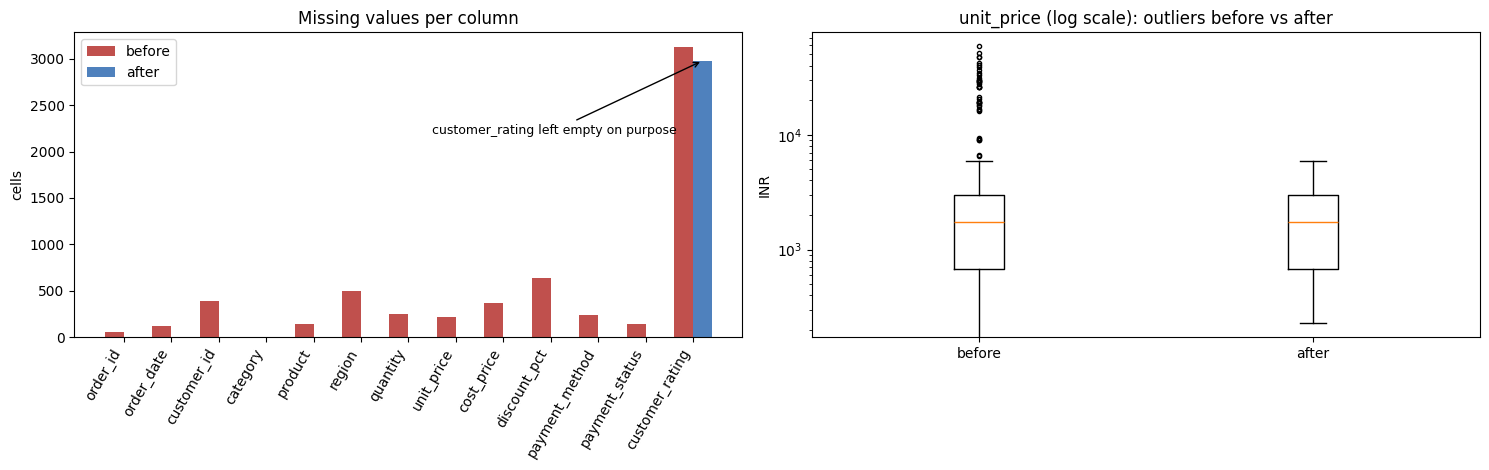

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.8))

# missing values per column
cols = list(raw.columns)
b = before_missing[cols]
a = clean[cols].isna().sum()
x = np.arange(len(cols)); w = 0.4
ax[0].bar(x - w/2, b, w, label="before", color="#c0504d")
ax[0].bar(x + w/2, a, w, label="after", color="#4f81bd")
ax[0].set_xticks(x); ax[0].set_xticklabels(cols, rotation=60, ha="right")
ax[0].set_title("Missing values per column"); ax[0].set_ylabel("cells"); ax[0].legend()
ax[0].annotate("customer_rating left empty on purpose", xy=(len(cols) - 1 + w/2, a["customer_rating"]), xytext=(len(cols) - 6.5, b.max() * 0.7),
               arrowprops=dict(arrowstyle="->"), fontsize=9)

# unit price: raw parsed vs clean (log scale so the x10 typos are visible)
raw_price = to_number(raw["unit_price"].where(~is_missing["unit_price"]))
ax[1].boxplot([raw_price.dropna(), clean["unit_price"]], tick_labels=["before", "after"], showfliers=True, flierprops=dict(markersize=3))
ax[1].set_yscale("log"); ax[1].set_title("unit_price (log scale): outliers before vs after"); ax[1].set_ylabel("INR")
plt.tight_layout(); plt.show()

### 11.4 What the clean data now allows (feature engineering payoff)

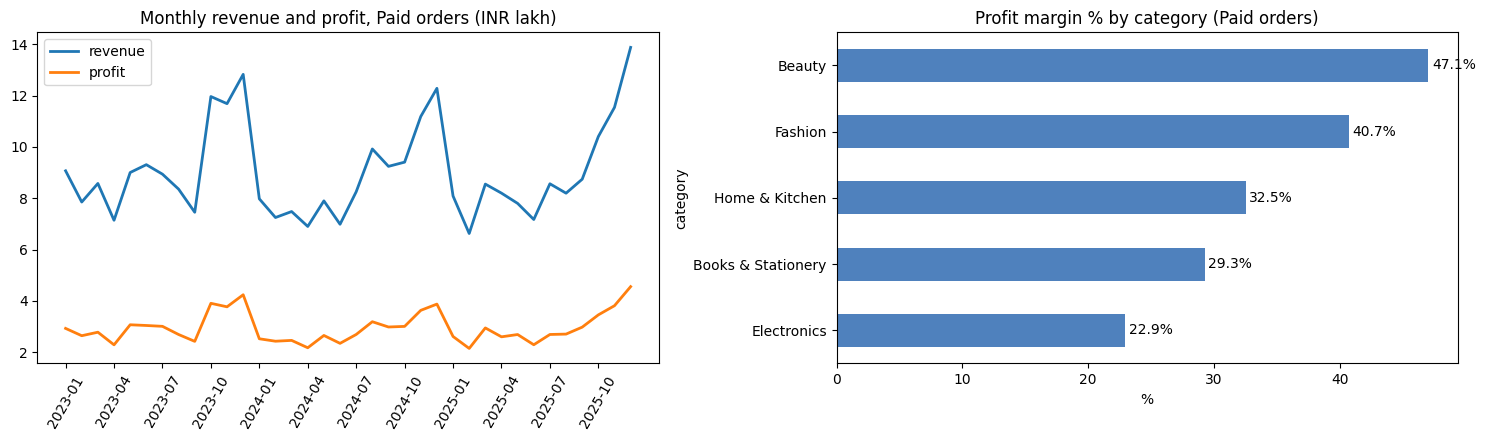

,revenue,profit,margin_pct
year,,,
2023,11217568.0,3680044.0,32.8
2024,10478693.0,3397641.0,32.4
2025,10776512.0,3550021.0,32.9


In [14]:
paid = clean[clean["counts_as_revenue"]]
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))

monthly = paid.groupby("year_month")[["revenue", "profit"]].sum() / 1e5
monthly.plot(ax=ax[0], lw=2)
ax[0].set_title("Monthly revenue and profit, Paid orders (INR lakh)"); ax[0].set_xlabel(""); ax[0].tick_params(axis="x", rotation=60)
ax[0].set_xticks(range(0, len(monthly), 3)); ax[0].set_xticklabels(monthly.index[::3])

margin = (paid.groupby("category")["profit"].sum() / paid.groupby("category")["revenue"].sum() * 100).sort_values()
margin.plot.barh(ax=ax[1], color="#4f81bd"); ax[1].set_title("Profit margin % by category (Paid orders)"); ax[1].set_xlabel("%")
for i, v in enumerate(margin): ax[1].text(v + 0.3, i, f"{v:.1f}%", va="center")
plt.tight_layout(); plt.show()

display(paid.groupby("year")[["revenue", "profit"]].sum().round(0).assign(margin_pct=lambda t: (t.profit / t.revenue * 100).round(1)))

## 12. Cross-check against the generator log (possible because the data is synthetic)

In [15]:
import json, os
if os.path.exists("generation_log.json"):
    log = json.load(open("generation_log.json"))
    print("clean rows expected from generator :", log["expected_clean_rows"])
    print("clean rows produced by this notebook:", len(clean))
    assert len(clean) == log["expected_clean_rows"], "row count does not match the generator's ground truth"
    inj = log["injected"]
    inj_total = inj["exact duplicate rows"] + inj["near-duplicate rows (same values, different formatting)"]
    removed_total = before["exact_dups"] + near_dups
    print(f"duplicates injected: {inj_total} (300 exact + 120 re-typed) | removed: {removed_total} ({before['exact_dups']} exact + {near_dups} hidden)")
    print("(a re-typed copy can happen to match its original exactly, so the exact/hidden split can differ by 1)")
    assert inj_total == removed_total, "duplicate count does not match the generator's ground truth"
    print("matches ground truth: OK")
else:
    print("generation_log.json not found - skipping the ground-truth check.")

clean rows expected from generator : 11822
clean rows produced by this notebook: 11822
duplicates injected: 420 (300 exact + 120 re-typed) | removed: 420 (301 exact + 119 hidden)
(a re-typed copy can happen to match its original exactly, so the exact/hidden split can differ by 1)
matches ground truth: OK


## 13. Conclusions

* The raw extract had duplicates (exact **and** hidden ones that differ only in formatting), five date formats, currency/percent/word text inside numeric columns, up to five spellings per category, impossible values and gaps in nearly every column.
* The clean file has **one row per order**, correct types, one spelling per value, no impossible values, and no missing values except `customer_rating`, which was left empty on purpose.
* Every repaired cell is traceable through the `*_imputed` flags, so analysts can re-run any KPI with or without imputed values.
* **Assumptions to review:** blank discount = 0; DD/MM/YYYY date order; quantity capped at 10 per order; number words converted to digits; only `Paid` orders count as revenue (`counts_as_revenue`).